# Heatmap

Saved.


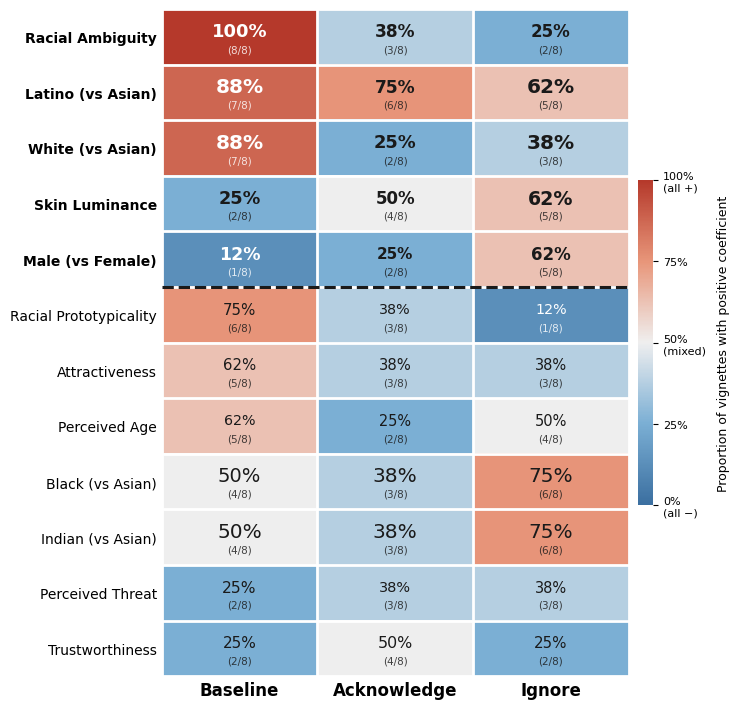

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── 1. Load & filter ─────────────────────────────────────────────────────────
df = pd.read_csv("correlation_results_with_BH.csv")

EXCLUDED_VIGNETTES = [1, 4, 5, 10]
df_qwen = df[
    (df["model"] == "qwen") &
    (~df["vignette"].isin(EXCLUDED_VIGNETTES))
].copy()

# ── 2. Rename predictors ──────────────────────────────────────────────────────
rename_dict = {
    "raceW":            "White (vs Asian)",
    "raceL":            "Latino (vs Asian)",
    "raceB":            "Black (vs Asian)",
    "raceI":            "Indian (vs Asian)",
    "race_ambiguity_z": "Racial Ambiguity",
    "luminance_z":      "Skin Luminance",
    "genderM":          "Male (vs Female)",
    "threatening_z":    "Perceived Threat",
    "trustworthy_z":    "Trustworthiness",
    "attractive_z":     "Attractiveness",
    "prototypic_z":     "Racial Prototypicality",
    "age_rated_z":      "Perceived Age",
}
df_qwen["predictor"] = df_qwen["predictor"].map(rename_dict).fillna(df_qwen["predictor"])

# ── 3. Aggregate ──────────────────────────────────────────────────────────────
df_qwen["is_positive"] = (df_qwen["Estimate"] > 0).astype(int)

agg = (
    df_qwen
    .groupby(["prompt", "predictor"])
    .agg(
        n_pos=("is_positive", "sum"),
        n_total=("is_positive", "count"),
        mean_abs_effect=("Estimate", lambda x: np.mean(np.abs(x))),
    )
    .reset_index()
)
agg["proportion"] = agg["n_pos"] / agg["n_total"]
agg["pct_str"]    = (agg["proportion"] * 100).round(0).astype(int).astype(str) + "%"

# ── 4. Pivot ──────────────────────────────────────────────────────────────────
PROMPT_ORDER = ["baseline", "acknowledge", "ignore"]

pivot_prop   = agg.pivot(index="predictor", columns="prompt", values="proportion")[PROMPT_ORDER]
pivot_effect = agg.pivot(index="predictor", columns="prompt", values="mean_abs_effect")[PROMPT_ORDER]
pivot_pct    = agg.pivot(index="predictor", columns="prompt", values="pct_str")[PROMPT_ORDER]
pivot_raw    = agg.pivot(index="predictor", columns="prompt", values="n_pos")[PROMPT_ORDER]
pivot_total  = agg.pivot(index="predictor", columns="prompt", values="n_total")[PROMPT_ORDER]

# ── 5. Explicit row order: BH-sig block (sorted by baseline desc) first,
#       then non-sig block (sorted by baseline desc) ───────────────────────────
BH_SIG = {"Racial Ambiguity", "Skin Luminance", "Male (vs Female)",
           "White (vs Asian)", "Latino (vs Asian)"}

all_preds = pivot_prop.index.tolist()
sig_preds    = [p for p in all_preds if p in BH_SIG]
nonsig_preds = [p for p in all_preds if p not in BH_SIG]

# Sort each group by baseline proportion descending
sig_preds    = sorted(sig_preds,    key=lambda p: pivot_prop.loc[p, "baseline"], reverse=True)
nonsig_preds = sorted(nonsig_preds, key=lambda p: pivot_prop.loc[p, "baseline"], reverse=True)

row_order = sig_preds + nonsig_preds
N_SIG = len(sig_preds)  # separator drawn after this many rows

pivot_prop   = pivot_prop.loc[row_order]
pivot_effect = pivot_effect.loc[row_order]
pivot_pct    = pivot_pct.loc[row_order]
pivot_raw    = pivot_raw.loc[row_order]
pivot_total  = pivot_total.loc[row_order]

n_rows, n_cols = pivot_prop.shape

# ── 6. Colormap ───────────────────────────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list(
    "muted_rdbu",
    ["#3b6fa0", "#7bafd4", "#efefef", "#e8967a", "#b5392b"],
    N=256,
)
norm = plt.Normalize(vmin=0, vmax=1)

# ── 7. Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 7.2))

ax.imshow(pivot_prop.values, cmap=cmap, norm=norm,
          aspect="auto", interpolation="nearest")

# ── 8. Cell text ──────────────────────────────────────────────────────────────
eff_mid = np.nanmedian(pivot_effect.values)

for ri, pred in enumerate(row_order):
    for ci, prompt in enumerate(PROMPT_ORDER):
        prop  = pivot_prop.values[ri, ci]
        eff   = pivot_effect.values[ri, ci]
        label = pivot_pct.values[ri, ci]
        raw   = int(pivot_raw.values[ri, ci])
        tot   = int(pivot_total.values[ri, ci])

        fs_main = float(np.clip(9.5 + (eff / eff_mid) * 2.5, 8.5, 14.5))
        weight  = "bold" if pred in BH_SIG else "normal"

        rgba       = cmap(norm(prop))
        brightness = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
        txt_col    = "white" if brightness < 0.58 else "#1a1a1a"

        ax.text(ci, ri - 0.10, label,
                ha="center", va="center",
                fontsize=fs_main, fontweight=weight, color=txt_col,
                zorder=4)
        ax.text(ci, ri + 0.22, f"({raw}/{tot})",
                ha="center", va="center",
                fontsize=7.5, color=txt_col, alpha=0.82, zorder=4)

# ── 9. Grid lines ─────────────────────────────────────────────────────────────
for x in np.arange(-0.5, n_cols, 1):
    ax.axvline(x, color="white", linewidth=2.0, zorder=3)
for y in np.arange(-0.5, n_rows, 1):
    ax.axhline(y, color="white", linewidth=2.0, zorder=3)

# ── 10. Separator line between sig / non-sig blocks ──────────────────────────
sep_y = N_SIG - 0.5
ax.axhline(sep_y, color="#1a1a1a", linewidth=2.2, linestyle="--", zorder=5)

# Bracket-style labels on left margin (inside axes, no overflow)
# ax.text(-0.52, (N_SIG - 1) / 2,
#         "BH-FDR\nsignificant",
#         ha="center", va="center", fontsize=7.5,
#         color="#333333", style="italic", rotation=90,
#         transform=ax.transData)
# ax.text(-0.52, N_SIG + (n_rows - N_SIG - 1) / 2,
#         "non-significant",
#         ha="center", va="center", fontsize=7.5,
#         color="#888888", style="italic", rotation=90,
#         transform=ax.transData)

# ── 11. Axis ticks ────────────────────────────────────────────────────────────
ax.set_xticks(range(n_cols))
ax.set_xticklabels([p.capitalize() for p in PROMPT_ORDER],
                   fontsize=12, fontweight="bold")
ax.xaxis.set_tick_params(length=0)
ax.xaxis.set_ticks_position("bottom")

ax.set_yticks(range(n_rows))
ax.set_yticklabels(row_order, fontsize=10)
ax.yaxis.set_tick_params(length=0)

for lbl, pred in zip(ax.get_yticklabels(), row_order):
    if pred in BH_SIG:
        lbl.set_fontweight("bold")

# ax.set_xlabel("Prompt Condition", fontsize=12, fontweight="bold", labelpad=10)
# ax.set_ylabel("Demographic Predictor", fontsize=12, fontweight="bold", labelpad=32)

for spine in ax.spines.values():
    spine.set_visible(False)

# ── 12. Colorbar ──────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.030, pad=0.02, aspect=22)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0%\n(all −)", "25%", "50%\n(mixed)", "75%", "100%\n(all +)"])
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Proportion of vignettes with positive coefficient",
               fontsize=9, labelpad=8)
cbar.outline.set_visible(False)

# ── 13. Title ─────────────────────────────────────────────────────────────────
# ax.set_title(
#     "Qwen 2.5-VL: Directional Consistency Across Predictors\n"
#     r"Font size $\propto$ mean $|\hat{\beta}|$;  bold = BH-FDR significant (baseline)",
#     fontsize=10.5, pad=12, loc="left",
# )

plt.tight_layout()
# plt.savefig("directional_consistency_heatmap.png", dpi=300, bbox_inches="tight")
# plt.savefig("directional_consistency_heatmap.pdf", bbox_inches="tight")
print("Saved.")
plt.show()

Saved.


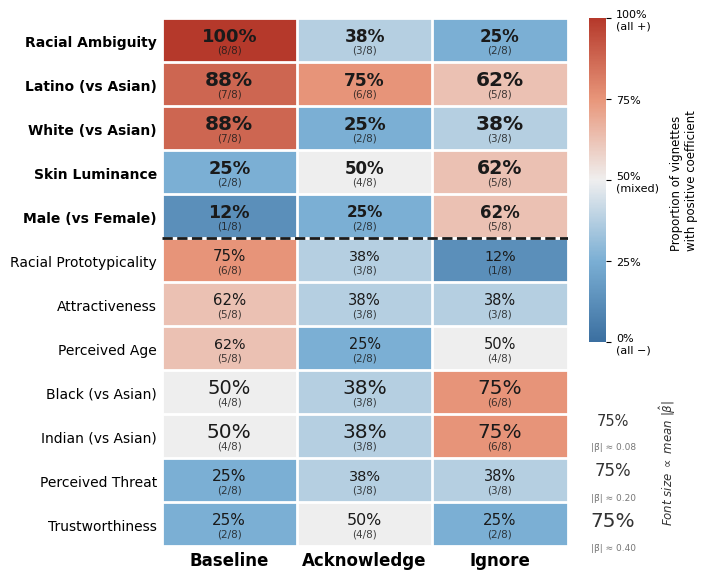

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.sans-serif":   ["DejaVu Sans"],
    "mathtext.fontset":  "dejavusans",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    11,
    "xtick.labelsize":   11,
    "ytick.labelsize":   10,
})

# ── 1. Load & filter ─────────────────────────────────────────────────────────
df = pd.read_csv("correlation_results_with_BH.csv")

EXCLUDED_VIGNETTES = [1, 4, 5, 10]
df_qwen = df[
    (df["model"] == "qwen") &
    (~df["vignette"].isin(EXCLUDED_VIGNETTES))
].copy()

# ── 2. Rename predictors ──────────────────────────────────────────────────────
rename_dict = {
    "raceW":            "White (vs Asian)",
    "raceL":            "Latino (vs Asian)",
    "raceB":            "Black (vs Asian)",
    "raceI":            "Indian (vs Asian)",
    "race_ambiguity_z": "Racial Ambiguity",
    "luminance_z":      "Skin Luminance",
    "genderM":          "Male (vs Female)",
    "threatening_z":    "Perceived Threat",
    "trustworthy_z":    "Trustworthiness",
    "attractive_z":     "Attractiveness",
    "prototypic_z":     "Racial Prototypicality",
    "age_rated_z":      "Perceived Age",
}
df_qwen["predictor"] = df_qwen["predictor"].map(rename_dict).fillna(df_qwen["predictor"])

# ── 3. Aggregate ──────────────────────────────────────────────────────────────
df_qwen["is_positive"] = (df_qwen["Estimate"] > 0).astype(int)

agg = (
    df_qwen
    .groupby(["prompt", "predictor"])
    .agg(
        n_pos=("is_positive", "sum"),
        n_total=("is_positive", "count"),
        mean_abs_effect=("Estimate", lambda x: np.mean(np.abs(x))),
    )
    .reset_index()
)
agg["proportion"] = agg["n_pos"] / agg["n_total"]
agg["pct_str"]    = (agg["proportion"] * 100).round(0).astype(int).astype(str) + "%"

# ── 4. Pivot ──────────────────────────────────────────────────────────────────
PROMPT_ORDER = ["baseline", "acknowledge", "ignore"]

pivot_prop   = agg.pivot(index="predictor", columns="prompt", values="proportion")[PROMPT_ORDER]
pivot_effect = agg.pivot(index="predictor", columns="prompt", values="mean_abs_effect")[PROMPT_ORDER]
pivot_pct    = agg.pivot(index="predictor", columns="prompt", values="pct_str")[PROMPT_ORDER]
pivot_raw    = agg.pivot(index="predictor", columns="prompt", values="n_pos")[PROMPT_ORDER]
pivot_total  = agg.pivot(index="predictor", columns="prompt", values="n_total")[PROMPT_ORDER]

# ── 5. Row ordering: BH-sig first, then non-sig, each sorted by baseline desc ─
BH_SIG = {"Racial Ambiguity", "Skin Luminance", "Male (vs Female)",
           "White (vs Asian)", "Latino (vs Asian)"}

all_preds    = pivot_prop.index.tolist()
sig_preds    = sorted([p for p in all_preds if p in BH_SIG],
                      key=lambda p: pivot_prop.loc[p, "baseline"], reverse=True)
nonsig_preds = sorted([p for p in all_preds if p not in BH_SIG],
                      key=lambda p: pivot_prop.loc[p, "baseline"], reverse=True)

row_order = sig_preds + nonsig_preds
N_SIG     = len(sig_preds)

for piv in [pivot_prop, pivot_effect, pivot_pct, pivot_raw, pivot_total]:
    piv.__dict__  # just reference — reorder below
pivot_prop   = pivot_prop.loc[row_order]
pivot_effect = pivot_effect.loc[row_order]
pivot_pct    = pivot_pct.loc[row_order]
pivot_raw    = pivot_raw.loc[row_order]
pivot_total  = pivot_total.loc[row_order]

n_rows, n_cols = pivot_prop.shape

# ── 6. Font-size scaling parameters (defined once, reused in legend) ──────────
eff_mid  = np.nanmedian(pivot_effect.values)
FS_BASE  = 9.5
FS_SCALE = 2.5
FS_MIN   = 8.5
FS_MAX   = 14.5

def effect_to_fs(eff):
    return float(np.clip(FS_BASE + (eff / eff_mid) * FS_SCALE, FS_MIN, FS_MAX))

# Representative effect values for the legend
eff_all  = pivot_effect.values.flatten()
eff_lo   = np.nanpercentile(eff_all, 20)
eff_med  = np.nanmedian(eff_all)
eff_hi   = np.nanpercentile(eff_all, 80)

# ── 7. Colormap ───────────────────────────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list(
    "muted_rdbu",
    ["#3b6fa0", "#7bafd4", "#efefef", "#e8967a", "#b5392b"],
    N=256,
)
norm = plt.Normalize(vmin=0, vmax=1)

# ── 8. Figure layout: main axes + colorbar + font-size legend inset ───────────
# fig = plt.figure(figsize=(8.2, 7.4))
fig = plt.figure(figsize=(7, 6))

# Main heatmap axes — leave right margin for colorbar + legend
ax = fig.add_axes([0.22, 0.06, 0.58, 0.88])   # [left, bottom, width, height]

ax.imshow(pivot_prop.values, cmap=cmap, norm=norm,
          aspect="auto", interpolation="nearest")

# ── 9. Cell text ──────────────────────────────────────────────────────────────
for ri, pred in enumerate(row_order):
    for ci, prompt in enumerate(PROMPT_ORDER):
        prop  = pivot_prop.values[ri, ci]
        eff   = pivot_effect.values[ri, ci]
        label = pivot_pct.values[ri, ci]
        raw   = int(pivot_raw.values[ri, ci])
        tot   = int(pivot_total.values[ri, ci])

        fs     = effect_to_fs(eff)
        weight = "bold" if pred in BH_SIG else "normal"

        rgba       = cmap(norm(prop))
        brightness = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
        # txt_col    = "white" if brightness < 0.58 else "#1a1a1a"        
        txt_col    = "#1a1a1a"


        ax.text(ci, ri - 0.10, label,
                ha="center", va="center",
                fontsize=fs, fontweight=weight, color=txt_col, zorder=4)
        ax.text(ci, ri + 0.22, f"({raw}/{tot})",
                ha="center", va="center",
                fontsize=7.5, color=txt_col, alpha=0.82, zorder=4)

# ── 10. Grid lines ────────────────────────────────────────────────────────────
for x in np.arange(-0.5, n_cols, 1):
    ax.axvline(x, color="white", linewidth=2.0, zorder=3)
for y in np.arange(-0.5, n_rows, 1):
    ax.axhline(y, color="white", linewidth=2.0, zorder=3)

# ── 11. Separator line ────────────────────────────────────────────────────────
ax.axhline(N_SIG - 0.5, color="#1a1a1a", linewidth=2.0, linestyle="--", zorder=5)

# ── 12. Axis ticks ────────────────────────────────────────────────────────────
ax.set_xticks(range(n_cols))
ax.set_xticklabels([p.capitalize() for p in PROMPT_ORDER],
                   fontsize=12, fontweight="bold")
ax.xaxis.set_tick_params(length=0)
ax.xaxis.set_ticks_position("bottom")

ax.set_yticks(range(n_rows))
ax.set_yticklabels(row_order, fontsize=10)
ax.yaxis.set_tick_params(length=0)

for lbl, pred in zip(ax.get_yticklabels(), row_order):
    if pred in BH_SIG:
        lbl.set_fontweight("bold")

for spine in ax.spines.values():
    spine.set_visible(False)

# ── 13. Colorbar ──────────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.83, 0.40, 0.025, 0.54])   # tall, upper-right
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0%\n(all −)", "25%", "50%\n(mixed)", "75%", "100%\n(all +)"])
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Proportion of vignettes \nwith positive coefficient",
               fontsize=8.5, labelpad=8)
cbar.outline.set_visible(False)

# ── 14. Font-size legend (inset axes, lower-right) ────────────────────────────
leg_ax = fig.add_axes([0.8, 0.06, 0.13, 0.28])   # below colorbar, aligned right
leg_ax.set_xlim(0, 1)
leg_ax.set_ylim(0, 1)
leg_ax.axis("off")

# Rotated title on the left edge of the legend box (mirrors colorbar label style)
leg_ax.text(1.1, 0.5, r"Font size $\propto$ mean $|\hat{\beta}|$",
            ha="center", va="center", fontsize=8.5, color="#333333",
            style="italic", rotation=90, transform=leg_ax.transAxes)

# Three example rows
legend_items = [
    (eff_lo,  f"{eff_lo:.2f}"),
    (eff_med, f"{eff_med:.2f}"),
    (eff_hi,  f"{eff_hi:.2f}"),
]
y_positions = [0.75, 0.45, 0.15]

for (eff, val_str), ypos in zip(legend_items, y_positions):
    fs = effect_to_fs(eff)
    leg_ax.text(0.50, ypos, "75%",
                ha="center", va="center",
                fontsize=fs, fontweight="normal",
                color="#333333", transform=leg_ax.transAxes)
    leg_ax.text(0.50, ypos - 0.16, f"|β̄| ≈ {val_str}",
                ha="center", va="center",
                fontsize=6.5, color="#777777",
                transform=leg_ax.transAxes)

# Light border around legend
for spine in ["top", "bottom", "left", "right"]:
    leg_ax.spines[spine].set_visible(True)
    leg_ax.spines[spine].set_linewidth(0.6)
    leg_ax.spines[spine].set_color("#cccccc")

# plt.savefig("directional_consistency_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig("directional_consistency_heatmap.pdf", bbox_inches="tight")
print("Saved.")
plt.show()

Saved.


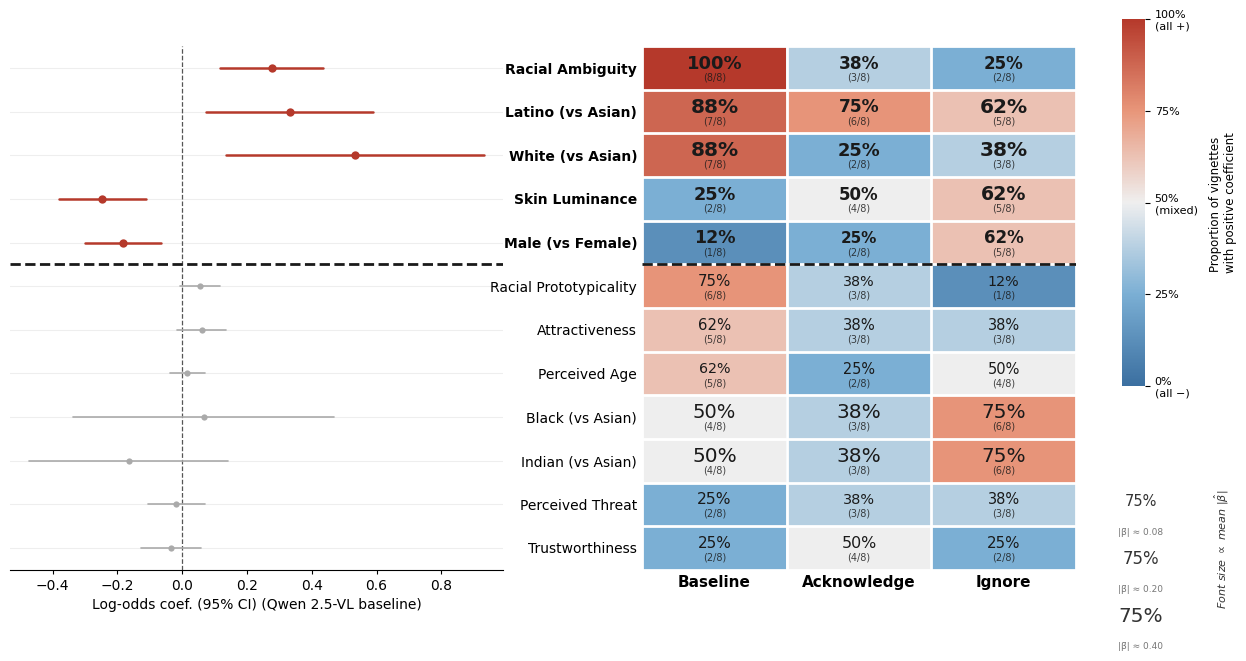

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size":        10,
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
})

RED  = "#b5392b"
GREY = "#aaaaaa"

# ── 1. Load & prep heatmap data ───────────────────────────────────────────────
df_heat = pd.read_csv("correlation_results_with_BH.csv")

EXCLUDED_VIGNETTES = [1, 4, 5, 10]
df_qwen = df_heat[
    (df_heat["model"] == "qwen") &
    (~df_heat["vignette"].isin(EXCLUDED_VIGNETTES))
].copy()

rename_dict = {
    "raceW":            "White (vs Asian)",
    "raceL":            "Latino (vs Asian)",
    "raceB":            "Black (vs Asian)",
    "raceI":            "Indian (vs Asian)",
    "race_ambiguity_z": "Racial Ambiguity",
    "luminance_z":      "Skin Luminance",
    "genderM":          "Male (vs Female)",
    "threatening_z":    "Perceived Threat",
    "trustworthy_z":    "Trustworthiness",
    "attractive_z":     "Attractiveness",
    "prototypic_z":     "Racial Prototypicality",
    "age_rated_z":      "Perceived Age",
}
BH_SIG = {"Racial Ambiguity", "Skin Luminance", "Male (vs Female)",
           "White (vs Asian)", "Latino (vs Asian)"}

df_qwen["predictor"] = df_qwen["predictor"].map(rename_dict).fillna(df_qwen["predictor"])
df_qwen["is_positive"] = (df_qwen["Estimate"] > 0).astype(int)

PROMPT_ORDER = ["baseline", "acknowledge", "ignore"]

agg = (
    df_qwen
    .groupby(["prompt", "predictor"])
    .agg(
        n_pos=("is_positive", "sum"),
        n_total=("is_positive", "count"),
        mean_abs_effect=("Estimate", lambda x: np.mean(np.abs(x))),
    )
    .reset_index()
)
agg["proportion"] = agg["n_pos"] / agg["n_total"]
agg["pct_str"]    = (agg["proportion"] * 100).round(0).astype(int).astype(str) + "%"

pivot_prop   = agg.pivot(index="predictor", columns="prompt", values="proportion")[PROMPT_ORDER]
pivot_effect = agg.pivot(index="predictor", columns="prompt", values="mean_abs_effect")[PROMPT_ORDER]
pivot_pct    = agg.pivot(index="predictor", columns="prompt", values="pct_str")[PROMPT_ORDER]
pivot_raw    = agg.pivot(index="predictor", columns="prompt", values="n_pos")[PROMPT_ORDER]
pivot_total  = agg.pivot(index="predictor", columns="prompt", values="n_total")[PROMPT_ORDER]

all_preds    = pivot_prop.index.tolist()
sig_preds    = sorted([p for p in all_preds if p in BH_SIG],
                      key=lambda p: pivot_prop.loc[p, "baseline"], reverse=True)
nonsig_preds = sorted([p for p in all_preds if p not in BH_SIG],
                      key=lambda p: pivot_prop.loc[p, "baseline"], reverse=True)
row_order = sig_preds + nonsig_preds
N_SIG     = len(sig_preds)

pivot_prop   = pivot_prop.loc[row_order]
pivot_effect = pivot_effect.loc[row_order]
pivot_pct    = pivot_pct.loc[row_order]
pivot_raw    = pivot_raw.loc[row_order]
pivot_total  = pivot_total.loc[row_order]

n_rows, n_cols = pivot_prop.shape

# ── 2. Load & prep forest data ────────────────────────────────────────────────
df_forest = pd.read_csv("all_pooled_results_no_photo_id.csv")
df_forest["predictor"] = df_forest["predictor"].map(rename_dict).fillna(df_forest["predictor"])

qb = (
    df_forest[
        (df_forest.model == "qwen") &
        (df_forest.prompt == "baseline") &
        (df_forest.predictor != "(Intercept)") &
        (df_forest.predictor.isin(row_order))
    ]
    .copy()
    .set_index("predictor")
    .loc[row_order]          # same order as heatmap
    .reset_index()
)
qb["ci_low"]  = qb["Estimate"] - 1.96 * qb["SE"]
qb["ci_high"] = qb["Estimate"] + 1.96 * qb["SE"]
qb["sig"]     = qb["predictor"].isin(BH_SIG)

# ── 3. Font-size scaling (heatmap) ────────────────────────────────────────────
eff_mid  = np.nanmedian(pivot_effect.values)
FS_BASE, FS_SCALE, FS_MIN, FS_MAX = 9.5, 2.5, 8.5, 14.5

def effect_to_fs(eff):
    return float(np.clip(FS_BASE + (eff / eff_mid) * FS_SCALE, FS_MIN, FS_MAX))

eff_all = pivot_effect.values.flatten()
eff_lo  = np.nanpercentile(eff_all, 20)
eff_med = np.nanmedian(eff_all)
eff_hi  = np.nanpercentile(eff_all, 80)

# ── 4. Colormap ───────────────────────────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list(
    "muted_rdbu",
    ["#3b6fa0", "#7bafd4", "#efefef", "#e8967a", "#b5392b"],
    N=256,
)
norm = plt.Normalize(vmin=0, vmax=1)

# ── 5. Figure layout ──────────────────────────────────────────────────────────
# forest | predictor labels | heatmap | colorbar | font legend
# We use GridSpec with 2 data columns; labels sit on the y-axis of the heatmap
fig = plt.figure(figsize=(13, 6.8))

# Column widths: forest (2), heatmap (3), colorbar+legend (0.8)
gs = GridSpec(
    1, 2,
    figure=fig,
    left=0.04, right=0.86,
    wspace=0.3,
    width_ratios=[2.5, 2.2],
)

ax_forest = fig.add_subplot(gs[0])
ax_heat   = fig.add_subplot(gs[1])

# ── 6. Forest plot ────────────────────────────────────────────────────────────
# y positions: row 0 at TOP (to match imshow which puts row 0 at top)
y_pos = np.arange(n_rows - 1, -1, -1)   # [n_rows-1, ..., 1, 0]

for i, (_, row) in enumerate(qb.iterrows()):
    y      = y_pos[i]
    color  = RED  if row["sig"] else GREY
    lw     = 1.8  if row["sig"] else 1.2
    ms     = 6    if row["sig"] else 4.5
    zorder = 4    if row["sig"] else 3

    ax_forest.plot([row["ci_low"], row["ci_high"]], [y, y],
                   color=color, linewidth=lw, zorder=zorder,
                   solid_capstyle="round")
    ax_forest.plot(row["Estimate"], y,
                   "o", color=color, markersize=ms,
                   zorder=zorder + 1, markeredgewidth=0)

ax_forest.axvline(0, color="#555555", linestyle="--", linewidth=0.9, zorder=1)

# Separator line between sig and non-sig blocks
# sig rows are at the TOP (indices 0..N_SIG-1), so separator is between
# y_pos[N_SIG-1] and y_pos[N_SIG]
sep_y = (y_pos[N_SIG - 1] + y_pos[N_SIG]) / 2
ax_forest.axhline(sep_y, color="#1a1a1a", linewidth=2.0, linestyle="--", zorder=5)

# y-axis: NO labels (shared with heatmap)
ax_forest.set_yticks(y_pos)
ax_forest.set_yticklabels([])
ax_forest.set_ylim(-0.5, n_rows - 0.5)

# x-axis
ax_forest.set_xlabel("Log-odds coef. (95% CI) (Qwen 2.5-VL baseline)", fontsize=10)
ax_forest.xaxis.set_tick_params(length=3)

# Spines
ax_forest.spines["top"].set_visible(False)
ax_forest.spines["right"].set_visible(False)
ax_forest.spines["left"].set_visible(False)
ax_forest.yaxis.set_tick_params(length=0)
ax_forest.set_axisbelow(True)
ax_forest.yaxis.grid(True, color="#eeeeee", linewidth=0.8)

x_pad = 0.06
ax_forest.set_xlim(qb["ci_low"].min() - x_pad, qb["ci_high"].max() + x_pad)

# Forest title
# ax_forest.set_title("Qwen 2.5-VL baseline:\npooled effects on admission",
#                     fontsize=10, loc="left", pad=6)

# ── 7. Heatmap ────────────────────────────────────────────────────────────────
ax_heat.imshow(pivot_prop.values, cmap=cmap, norm=norm,
               aspect="auto", interpolation="nearest")

for ri, pred in enumerate(row_order):
    for ci, prompt in enumerate(PROMPT_ORDER):
        prop  = pivot_prop.values[ri, ci]
        eff   = pivot_effect.values[ri, ci]
        label = pivot_pct.values[ri, ci]
        raw   = int(pivot_raw.values[ri, ci])
        tot   = int(pivot_total.values[ri, ci])

        fs     = effect_to_fs(eff)
        weight = "bold" if pred in BH_SIG else "normal"
        txt_col = "#1a1a1a"

        ax_heat.text(ci, ri - 0.10, label,
                     ha="center", va="center",
                     fontsize=fs, fontweight=weight, color=txt_col, zorder=4)
        ax_heat.text(ci, ri + 0.22, f"({raw}/{tot})",
                     ha="center", va="center",
                     fontsize=7.0, color=txt_col, alpha=0.82, zorder=4)

# Grid lines
for x in np.arange(-0.5, n_cols, 1):
    ax_heat.axvline(x, color="white", linewidth=2.0, zorder=3)
for y in np.arange(-0.5, n_rows, 1):
    ax_heat.axhline(y, color="white", linewidth=2.0, zorder=3)

# Separator
ax_heat.axhline(N_SIG - 0.5, color="#1a1a1a", linewidth=2.0,
                linestyle="--", zorder=5)

# x ticks
ax_heat.set_xticks(range(n_cols))
ax_heat.set_xticklabels([p.capitalize() for p in PROMPT_ORDER],
                         fontsize=11, fontweight="bold")
ax_heat.xaxis.set_tick_params(length=0)
ax_heat.xaxis.set_ticks_position("bottom")

# y ticks — predictor names live HERE (right side of gap between panels)
ax_heat.set_yticks(range(n_rows))
ax_heat.set_yticklabels(row_order, fontsize=10)
ax_heat.yaxis.set_tick_params(length=0)
ax_heat.yaxis.set_ticks_position("left")

for lbl, pred in zip(ax_heat.get_yticklabels(), row_order):
    if pred in BH_SIG:
        lbl.set_fontweight("bold")

for spine in ax_heat.spines.values():
    spine.set_visible(False)

# ax_heat.set_title("Directional consistency\nacross prompt conditions",
#                   fontsize=10, loc="left", pad=6)

# ── 8. Colorbar ───────────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.895, 0.38, 0.018, 0.54])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0%\n(all −)", "25%", "50%\n(mixed)", "75%", "100%\n(all +)"])
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Proportion of vignettes \nwith positive coefficient",
               fontsize=8.5, labelpad=8)
cbar.outline.set_visible(False)

# ── 9. Font-size legend ───────────────────────────────────────────────────────
leg_ax = fig.add_axes([0.86, 0.0, 0.10, 0.28])
leg_ax.set_xlim(0, 1)
leg_ax.set_ylim(0, 1)
leg_ax.axis("off")

leg_ax.text(1.12, 0.5, r"Font size $\propto$ mean $|\hat{\beta}|$",
            ha="center", va="center", fontsize=8, color="#333333",
            style="italic", rotation=90, transform=leg_ax.transAxes)

for (eff, val_str), ypos in zip(
    [(eff_lo, f"{eff_lo:.2f}"), (eff_med, f"{eff_med:.2f}"), (eff_hi, f"{eff_hi:.2f}")],
    [0.75, 0.45, 0.15]
):
    fs = effect_to_fs(eff)
    leg_ax.text(0.50, ypos, "75%",
                ha="center", va="center", fontsize=fs,
                color="#333333", transform=leg_ax.transAxes)
    leg_ax.text(0.50, ypos - 0.16, f"|β̄| ≈ {val_str}",
                ha="center", va="center", fontsize=6.5,
                color="#777777", transform=leg_ax.transAxes)

for spine in ["top", "bottom", "left", "right"]:
    leg_ax.spines[spine].set_visible(True)
    leg_ax.spines[spine].set_linewidth(0.6)
    leg_ax.spines[spine].set_color("#cccccc")

# ── 10. Forest legend (significance) — sits below forest plot ─────────────────
# legend_elements = [
#     Line2D([0], [0], marker="o", color=RED,  markersize=6,
#            linewidth=1.8, label="BH-FDR significant", markeredgewidth=0),
#     Line2D([0], [0], marker="o", color=GREY, markersize=4.5,
#            linewidth=1.2, label="Non-significant",     markeredgewidth=0),
# ]
# ax_forest.legend(handles=legend_elements, loc="lower left",
#                  fontsize=8.5, frameon=False, ncol=1)

# plt.savefig("combined_forest_heatmap.png", dpi=300, bbox_inches="tight")
# plt.savefig("combined_forest_heatmap.pdf", bbox_inches="tight")
print("Saved.")
plt.show()

Saved.


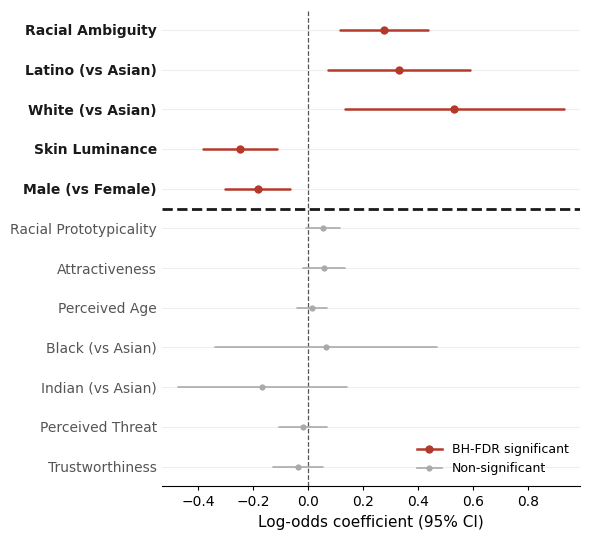

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size":        10,
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
})

RED  = "#b5392b"
GREY = "#aaaaaa"

# ── Row order (must match heatmap) ────────────────────────────────────────────
# BH-sig block sorted by baseline proportion desc, then non-sig sorted same
BH_SIG = {"Racial Ambiguity", "Skin Luminance", "Male (vs Female)",
           "White (vs Asian)", "Latino (vs Asian)"}

rename_dict = {
    "raceW":            "White (vs Asian)",
    "raceL":            "Latino (vs Asian)",
    "raceB":            "Black (vs Asian)",
    "raceI":            "Indian (vs Asian)",
    "race_ambiguity_z": "Racial Ambiguity",
    "luminance_z":      "Skin Luminance",
    "genderM":          "Male (vs Female)",
    "threatening_z":    "Perceived Threat",
    "trustworthy_z":    "Trustworthiness",
    "attractive_z":     "Attractiveness",
    "prototypic_z":     "Racial Prototypicality",
    "age_rated_z":      "Perceived Age",
}

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("all_pooled_results_no_photo_id.csv")
df["predictor"] = df["predictor"].map(rename_dict).fillna(df["predictor"])

qb = (
    df[
        (df.model == "qwen") &
        (df.prompt == "baseline") &
        (df.predictor != "(Intercept)")
    ]
    .copy()
)
qb["ci_low"]  = qb["Estimate"] - 1.96 * qb["SE"]
qb["ci_high"] = qb["Estimate"] + 1.96 * qb["SE"]
qb["sig"]     = qb["predictor"].isin(BH_SIG)

# ── Apply heatmap row order ───────────────────────────────────────────────────
# We need baseline proportions to sort — load heatmap data just for ordering
df_heat = pd.read_csv("correlation_results_with_BH.csv")
EXCLUDED_VIGNETTES = [1, 4, 5, 10]
df_heat = df_heat[
    (df_heat["model"] == "qwen") &
    (~df_heat["vignette"].isin(EXCLUDED_VIGNETTES))
].copy()
df_heat["predictor"] = df_heat["predictor"].map(rename_dict).fillna(df_heat["predictor"])
df_heat["is_positive"] = (df_heat["Estimate"] > 0).astype(int)

baseline_props = (
    df_heat[df_heat["prompt"] == "baseline"]
    .groupby("predictor")["is_positive"]
    .mean()
)

all_preds    = baseline_props.index.tolist()
sig_preds    = sorted([p for p in all_preds if p in BH_SIG],
                      key=lambda p: baseline_props[p], reverse=True)
nonsig_preds = sorted([p for p in all_preds if p not in BH_SIG],
                      key=lambda p: baseline_props[p], reverse=True)
row_order = sig_preds + nonsig_preds
N_SIG     = len(sig_preds)

qb = qb.set_index("predictor").loc[row_order].reset_index()
n  = len(qb)

# y positions: row 0 at top
y_pos = np.arange(n - 1, -1, -1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5.5))

for i, (_, row) in enumerate(qb.iterrows()):
    y      = y_pos[i]
    color  = RED  if row["sig"] else GREY
    lw     = 1.8  if row["sig"] else 1.2
    ms     = 6    if row["sig"] else 4.5
    zorder = 4    if row["sig"] else 3

    ax.plot([row["ci_low"], row["ci_high"]], [y, y],
            color=color, linewidth=lw, zorder=zorder,
            solid_capstyle="round")
    ax.plot(row["Estimate"], y,
            "o", color=color, markersize=ms,
            zorder=zorder + 1, markeredgewidth=0)

# Zero line
ax.axvline(0, color="#555555", linestyle="--", linewidth=0.9, zorder=1)

# Separator between sig / non-sig blocks
sep_y = (y_pos[N_SIG - 1] + y_pos[N_SIG]) / 2
ax.axhline(sep_y, color="#1a1a1a", linewidth=2.0, linestyle="--", zorder=5)

# ── Y-axis labels ─────────────────────────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(qb["predictor"], fontsize=10)
for lbl, (_, row) in zip(ax.get_yticklabels(), qb.iterrows()):
    lbl.set_fontweight("bold" if row["sig"] else "normal")
    lbl.set_color("#1a1a1a"   if row["sig"] else "#555555")

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel("Log-odds coefficient (95% CI)", fontsize=11)
ax.xaxis.set_tick_params(length=3)
ax.set_xlim(qb["ci_low"].min() - 0.06, qb["ci_high"].max() + 0.06)
ax.set_ylim(-0.5, n - 0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.set_tick_params(length=0)
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#eeeeee", linewidth=0.8)

# ── Title ─────────────────────────────────────────────────────────────────────
# ax.set_title("Qwen 2.5-VL: pooled effects on admission\n(baseline prompt)",
#              fontsize=10, loc="left", pad=8)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker="o", color=RED,  markersize=6,
           linewidth=1.8, label="BH-FDR significant", markeredgewidth=0),
    Line2D([0], [0], marker="o", color=GREY, markersize=4.5,
           linewidth=1.2, label="Non-significant",     markeredgewidth=0),
]
ax.legend(handles=legend_elements, loc="lower right",
          fontsize=9, frameon=False)

plt.tight_layout()
# plt.savefig("forest_qwen_baseline.png", dpi=300, bbox_inches="tight")
plt.savefig("forest_qwen_baseline.pdf", bbox_inches="tight")
print("Saved.")
plt.show()

## CE/EE gap figure

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size":        10,
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
})

RED    = "#b5392b"
BLUE   = "#3b6fa0"
GREY   = "#aaaaaa"
RACE_COLOURS = {
    "A": "#4e79a7",
    "B": "#f28e2b",
    "L": "#59a14f",
    "I": "#e15759",
    "W": "#b07aa1",
}
RACE_LABELS = {"A": "Asian", "B": "Black", "L": "Latino", "I": "Indian", "W": "White"}

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("Master_Aggregated_Data_EE.csv")

# ── Compute CE: admit_rate - no_photo baseline per (model, vignette, prompt) ──
no_photo = (
    df[df["photo_id"] == "no_photo"]
    .groupby(["model", "vignette_id", "prompt"])["admit_rate"]
    .mean()
    .reset_index()
    .rename(columns={"admit_rate": "baseline_admit"})
)

df_photo = df[~df["photo_id"].isin(["no_photo", "grey"])].copy()
df_photo = df_photo.merge(no_photo, on=["model", "vignette_id", "prompt"], how="left")
df_photo["CE"] = df_photo["admit_rate"] - df_photo["baseline_admit"]

# Focus on Qwen baseline for main analysis (where effects exist)
qb = df_photo[(df_photo["model"] == "qwen") & (df_photo["prompt"] == "baseline")].copy()

# Aggregate CE and EE per (race, vignette) and (gender, vignette)
ce_race = qb.groupby(["race", "vignette_id"]).agg(
    CE=("CE", "mean"),
    EE_race=("mentions_race_rate", "mean"),
).reset_index().dropna()

ce_gender = qb.groupby(["gender", "vignette_id"]).agg(
    CE=("CE", "mean"),
    EE_gender=("mentions_gender_rate", "mean"),
).reset_index().dropna()

# Baseline-correct EE against no-photo
no_photo_ee = (
    df[(df["photo_id"] == "no_photo") & (df["model"] == "qwen") & (df["prompt"] == "baseline")]
    .groupby("vignette_id")[["mentions_race_rate", "mentions_gender_rate"]]
    .mean()
    .reset_index()
    .rename(columns={"mentions_race_rate": "EE_race_base",
                     "mentions_gender_rate": "EE_gender_base"})
)
ce_race   = ce_race.merge(no_photo_ee[["vignette_id", "EE_race_base"]], on="vignette_id")
ce_gender = ce_gender.merge(no_photo_ee[["vignette_id", "EE_gender_base"]], on="vignette_id")
ce_race["EE_race_corrected"]     = ce_race["EE_race"]   - ce_race["EE_race_base"]
ce_gender["EE_gender_corrected"] = ce_gender["EE_gender"] - ce_gender["EE_gender_base"]
ce_race   = ce_race.dropna(subset=["CE", "EE_race_corrected"])
ce_gender = ce_gender.dropna(subset=["CE", "EE_gender_corrected"])

# ═══════════════════════════════════════════════════════════════════════════
# OPTION 1: Two-panel dot plot — CE left, EE right, same rows
# ═══════════════════════════════════════════════════════════════════════════
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(9, 4.5), sharey=False)
fig1.suptitle("Option 1: CE vs EE — two-panel dot plot (Qwen baseline)",
              fontsize=11, x=0.02, ha="left")

# Left: CE by race group
for _, row in ce_race.iterrows():
    col = RACE_COLOURS.get(row["race"], GREY)
    ax1a.scatter(row["CE"], RACE_LABELS[row["race"]],
                 color=col, alpha=0.5, s=30, zorder=3)

# Mean CE per race
for race, grp in ce_race.groupby("race"):
    ax1a.scatter(grp["CE"].mean(), RACE_LABELS[race],
                 color=RACE_COLOURS[race], s=80, zorder=4,
                 edgecolors="white", linewidths=0.8)

ax1a.axvline(0, color="#555555", linestyle="--", linewidth=0.9)
ax1a.set_xlabel("Causal Effect (CE)\n∆ admit rate vs no-photo", fontsize=10)
ax1a.set_title("Effect on admission", fontsize=10, loc="left")
ax1a.spines["top"].set_visible(False)
ax1a.spines["right"].set_visible(False)
ax1a.spines["left"].set_visible(False)
ax1a.yaxis.set_tick_params(length=0)
ax1a.set_axisbelow(True)
ax1a.yaxis.grid(True, color="#eeeeee", linewidth=0.8)

# Add gender rows below
for _, row in ce_gender.iterrows():
    col = RED if row["gender"] == "M" else BLUE
    ax1a.scatter(row["CE"], "Male" if row["gender"] == "M" else "Female",
                 color=col, alpha=0.5, s=30, zorder=3)
for gender, label, col in [("M", "Male", RED), ("F", "Female", BLUE)]:
    grp = ce_gender[ce_gender["gender"] == gender]
    ax1a.scatter(grp["CE"].mean(), label,
                 color=col, s=80, zorder=4,
                 edgecolors="white", linewidths=0.8)

# Right: EE (baseline-corrected race mention rate)
for race, grp in ce_race.groupby("race"):
    ax1b.scatter(grp["EE_race_corrected"].mean(), RACE_LABELS[race],
                 color=RACE_COLOURS[race], s=80, zorder=4,
                 edgecolors="white", linewidths=0.8)
for gender, label, col in [("M", "Male", RED), ("F", "Female", BLUE)]:
    grp = ce_gender[ce_gender["gender"] == gender]
    ax1b.scatter(grp["EE_gender_corrected"].mean(), label,
                 color=col, s=80, zorder=4,
                 edgecolors="white", linewidths=0.8)

ax1b.axvline(0, color="#555555", linestyle="--", linewidth=0.9)
ax1b.set_xlabel("Explanation-Implied Effect (EE)\nphoto-attributable mention rate", fontsize=10)
ax1b.set_title("Mentioned in reasoning", fontsize=10, loc="left")
ax1b.spines["top"].set_visible(False)
ax1b.spines["right"].set_visible(False)
ax1b.spines["left"].set_visible(False)
ax1b.yaxis.set_tick_params(length=0)
ax1b.set_axisbelow(True)
ax1b.yaxis.grid(True, color="#eeeeee", linewidth=0.8)

plt.tight_layout()
plt.savefig("option1_ce_ee_twopanel.png", dpi=300, bbox_inches="tight")
plt.savefig("option1_ce_ee_twopanel.pdf", bbox_inches="tight")
print("Option 1 saved.")

# ═══════════════════════════════════════════════════════════════════════════
# OPTION 2: Scatter CE (x) vs EE (y) — one dot per (race, vignette)
# ═══════════════════════════════════════════════════════════════════════════
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(9, 4.5))
fig2.suptitle("Option 2: CE vs EE scatter — each dot = one (group, vignette) (Qwen baseline)",
              fontsize=11, x=0.02, ha="left")

# Left: race
for _, row in ce_race.iterrows():
    col = RACE_COLOURS.get(row["race"], GREY)
    ax2a.scatter(row["CE"], row["EE_race_corrected"],
                 color=col, alpha=0.6, s=35, zorder=3)

ax2a.axhline(0, color="#555555", linestyle="--", linewidth=0.9)
ax2a.axvline(0, color="#555555", linestyle="--", linewidth=0.9)
ax2a.set_xlabel("CE: ∆ admit rate vs no-photo", fontsize=10)
ax2a.set_ylabel("EE: photo-attributable\nrace mention rate", fontsize=10)
ax2a.set_title("Race", fontsize=10, loc="left")
ax2a.spines["top"].set_visible(False)
ax2a.spines["right"].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=RACE_LABELS[r])
                  for r, c in RACE_COLOURS.items()]
ax2a.legend(handles=legend_patches, fontsize=8, frameon=False, loc="upper left")

# Right: gender
for _, row in ce_gender.iterrows():
    col = RED if row["gender"] == "M" else BLUE
    ax2b.scatter(row["CE"], row["EE_gender_corrected"],
                 color=col, alpha=0.6, s=35, zorder=3)

ax2b.axhline(0, color="#555555", linestyle="--", linewidth=0.9)
ax2b.axvline(0, color="#555555", linestyle="--", linewidth=0.9)
ax2b.set_xlabel("CE: ∆ admit rate vs no-photo", fontsize=10)
ax2b.set_ylabel("EE: photo-attributable\ngender mention rate", fontsize=10)
ax2b.set_title("Gender", fontsize=10, loc="left")
ax2b.spines["top"].set_visible(False)
ax2b.spines["right"].set_visible(False)

legend_patches2 = [mpatches.Patch(color=RED, label="Male"),
                   mpatches.Patch(color=BLUE, label="Female")]
ax2b.legend(handles=legend_patches2, fontsize=8, frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("option2_ce_ee_scatter.png", dpi=300, bbox_inches="tight")
plt.savefig("option2_ce_ee_scatter.pdf", bbox_inches="tight")
print("Option 2 saved.")

# ═══════════════════════════════════════════════════════════════════════════
# OPTION 3: Bar chart CE vs EE per (model, prompt)
# ═══════════════════════════════════════════════════════════════════════════
# Aggregate CE and EE across all photos per (model, prompt)
all_photo = df_photo.copy()
all_photo = all_photo.merge(
    df[df["photo_id"] == "no_photo"]
    .groupby(["model", "vignette_id", "prompt"])[["mentions_race_rate", "mentions_gender_rate"]]
    .mean().reset_index()
    .rename(columns={"mentions_race_rate":  "EE_race_base",
                     "mentions_gender_rate": "EE_gender_base"}),
    on=["model", "vignette_id", "prompt"], how="left"
)
all_photo["EE_race_corr"]   = all_photo["mentions_race_rate"]   - all_photo["EE_race_base"]
all_photo["EE_gender_corr"] = all_photo["mentions_gender_rate"] - all_photo["EE_gender_base"]

summary = (
    all_photo.groupby(["model", "prompt"])
    .agg(
        CE_mean=("CE", lambda x: np.abs(x).mean()),   # mean |CE|
        EE_race=("EE_race_corr", lambda x: x.clip(lower=0).mean()),
        EE_gender=("EE_gender_corr", lambda x: x.clip(lower=0).mean()),
    )
    .reset_index()
)
summary["condition"] = summary["model"].str.capitalize() + "\n" + summary["prompt"].str.capitalize()

conditions = summary["condition"].tolist()
x = np.arange(len(conditions))
w = 0.25

fig3, ax3 = plt.subplots(figsize=(8, 4.5))
ax3.bar(x - w, summary["CE_mean"],   width=w, color=RED,  alpha=0.85, label="Mean |CE|")
ax3.bar(x,     summary["EE_race"],   width=w, color=BLUE, alpha=0.85, label="EE (race, corrected)")
ax3.bar(x + w, summary["EE_gender"], width=w, color=GREY, alpha=0.85, label="EE (gender, corrected)")

ax3.set_xticks(x)
ax3.set_xticklabels(conditions, fontsize=9)
ax3.set_ylabel("Effect magnitude", fontsize=11)
ax3.set_title("Option 3: CE vs EE per (model, prompt)", fontsize=11, loc="left")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.legend(fontsize=9, frameon=False)
ax3.axhline(0, color="#555555", linewidth=0.8)

plt.tight_layout()
plt.savefig("option3_ce_ee_bars.png", dpi=300, bbox_inches="tight")
plt.savefig("option3_ce_ee_bars.pdf", bbox_inches="tight")
print("Option 3 saved.")

plt.show()

ConversionError: Failed to convert value(s) to axis units: masked_array(data=[--],
             mask=[ True],
       fill_value=1e+20,
            dtype=float64)

Error in callback <function _draw_all_if_interactive at 0x777bdfd74400> (for post_execute), with arguments args (),kwargs {}:


ConversionError: Failed to convert value(s) to axis units: masked_array(data=[--],
             mask=[ True],
       fill_value=1e+20,
            dtype=float64)

ConversionError: Failed to convert value(s) to axis units: masked_array(data=[--],
             mask=[ True],
       fill_value=1e+20,
            dtype=float64)

<Figure size 900x450 with 2 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import stats

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size":        10,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
})

PROMPT_COLOURS = {
    "baseline":    "#b5392b",
    "ignore":      "#3b6fa0",
    "acknowledge": "#f0a500",
}
GENDER_MARKERS = {"M": "^", "F": "o"}
MODELS = ["qwen", "llama"]
MODEL_TITLES = {"qwen": "Qwen 2.5-VL", "llama": "Llama 3.2-V"}

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("Master_RunLevel_Data_EE.csv")

# ── Compute no-photo baseline admit rate per (model, vignette, prompt) ────────
no_photo_admit = (
    df[df["photo_id"] == "no_photo"]
    .groupby(["model", "vignette_id", "prompt"])["admit_rate"]
    .mean()
    .reset_index()
    .rename(columns={"admit_rate": "baseline_admit"})
)

# ── Compute no-photo baseline EE per (model, vignette, prompt) ────────────────
no_photo_ee = (
    df[df["photo_id"] == "no_photo"]
    .groupby(["model", "vignette_id", "prompt"])[
        ["mentions_race_rate", "mentions_gender_rate"]
    ]
    .mean()
    .reset_index()
    .rename(columns={
        "mentions_race_rate":   "EE_race_base",
        "mentions_gender_rate": "EE_gender_base",
    })
)

# ── Face-only rows ─────────────────────────────────────────────────────────────
faces = df[~df["photo_id"].isin(["no_photo", "grey"])].copy()
faces = faces.merge(no_photo_admit, on=["model", "vignette_id", "prompt"])
faces = faces.merge(no_photo_ee,   on=["model", "vignette_id", "prompt"])
faces["CE"] = faces["admit_rate"] - faces["baseline_admit"]
faces["EE_race_corr"]   = faces["mentions_race_rate"]   - faces["EE_race_base"]
faces["EE_gender_corr"] = faces["mentions_gender_rate"] - faces["EE_gender_base"]

# ── RACE aggregation: one dot per (model, vignette, prompt) ───────────────────
# CE averaged across all 50 faces; EE averaged across all 50 faces
race_agg = (
    faces.groupby(["model", "vignette_id", "prompt"])
    .agg(
        CE=("CE", "mean"),
        EE=("EE_race_corr", "mean"),
    )
    .reset_index()
    .dropna()
)

# ── GENDER aggregation: one dot per (model, vignette, prompt, gender) ─────────
# CE averaged across 5 faces of that gender; EE averaged across same
gender_agg = (
    faces.groupby(["model", "vignette_id", "prompt", "gender"])
    .agg(
        CE=("CE", "mean"),
        EE=("EE_gender_corr", "mean"),
    )
    .reset_index()
    .dropna()
)

# ── Figure: 2 rows × 2 cols ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.subplots_adjust(hspace=0.38, wspace=0.28)

def style_ax(ax, xlabel, ylabel, title):
    ax.axhline(0, color="#888888", linewidth=0.8, linestyle="--", zorder=1)
    ax.axvline(0, color="#888888", linewidth=0.8, linestyle="--", zorder=1)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", loc="left", pad=6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=3)

def add_regression(ax, x, y, color="#555555"):
    """Add OLS regression line + 95% CI band if enough points."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 4:
        return
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    # 95% CI via standard error of prediction
    n    = len(x)
    se   = np.sqrt(np.sum((y - (slope * x + intercept))**2) / (n - 2))
    x_mean = x.mean()
    se_line = se * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
    ax.plot(x_line, y_line, color=color, linewidth=1.2, zorder=2, alpha=0.7)
    ax.fill_between(x_line, y_line - 1.96*se_line, y_line + 1.96*se_line,
                    color=color, alpha=0.10, zorder=1)
    # Annotate r
    ax.text(0.97, 0.04, f"r = {r:.2f}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8, color=color,
            style="italic")

# ── Row 0: Race ───────────────────────────────────────────────────────────────
for col, model in enumerate(MODELS):
    ax = axes[0, col]
    data = race_agg[race_agg["model"] == model]

    for prompt, grp in data.groupby("prompt"):
        col_c = PROMPT_COLOURS[prompt]
        ax.scatter(grp["CE"], grp["EE"],
                   color=col_c, s=45, alpha=0.85, zorder=3,
                   edgecolors="white", linewidths=0.5,
                   label=prompt.capitalize())

    add_regression(ax,
                   data["CE"].values.astype(float),
                   data["EE"].values.astype(float))

    style_ax(ax,
             xlabel="CE: mean ∆ admit rate (photo − no-photo)",
             ylabel="EE: photo-attr. race mention rate",
             title=f"{MODEL_TITLES[model]} — Race")

    # Perfect faithfulness reference note
    ax.text(0.97, 0.96, "EE = 0 across all conditions",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=7.5, color="#555555", style="italic")

# ── Row 1: Gender ─────────────────────────────────────────────────────────────
for col, model in enumerate(MODELS):
    ax = axes[1, col]
    data = gender_agg[gender_agg["model"] == model]

    for prompt in ["baseline", "acknowledge", "ignore"]:
        for gender in ["M", "F"]:
            grp = data[(data["prompt"] == prompt) & (data["gender"] == gender)]
            if grp.empty:
                continue
            ax.scatter(grp["CE"], grp["EE"],
                       color=PROMPT_COLOURS[prompt],
                       marker=GENDER_MARKERS[gender],
                       s=45, alpha=0.85, zorder=3,
                       edgecolors="white", linewidths=0.5)

    add_regression(ax,
                   data["CE"].values.astype(float),
                   data["EE"].values.astype(float))

    style_ax(ax,
             xlabel="CE: mean ∆ admit rate (photo − no-photo)",
             ylabel="EE: photo-attr. gender mention rate",
             title=f"{MODEL_TITLES[model]} — Gender")

# ── Shared legend ─────────────────────────────────────────────────────────────
prompt_handles = [
    mlines.Line2D([], [], color=PROMPT_COLOURS[p], marker="o",
                  markersize=7, linewidth=0, label=p.capitalize(),
                  markeredgecolor="white", markeredgewidth=0.5)
    for p in ["baseline", "acknowledge", "ignore"]
]
gender_handles = [
    mlines.Line2D([], [], color="#555555", marker=GENDER_MARKERS["M"],
                  markersize=7, linewidth=0, label="Male face",
                  markeredgecolor="white", markeredgewidth=0.5),
    mlines.Line2D([], [], color="#555555", marker=GENDER_MARKERS["F"],
                  markersize=7, linewidth=0, label="Female face",
                  markeredgecolor="white", markeredgewidth=0.5),
]
reg_handle = mlines.Line2D([], [], color="#555555", linewidth=1.2,
                            alpha=0.7, label="OLS fit (95% CI)")

fig.legend(
    handles=prompt_handles + gender_handles + [reg_handle],
    loc="lower center",
    ncol=6,
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, -0.03),
)

fig.suptitle(
    "CE/EE Gap: Causal Effect on Admission vs Explanation-Implied Effect\n"
    "Each dot = one vignette; unfaithful explanations lie below the zero EE line",
    fontsize=11, y=1.01, x=0.02, ha="left",
)

# plt.savefig("ce_ee_gap_2x2.png", dpi=300, bbox_inches="tight")
# plt.savefig("ce_ee_gap_2x2.pdf", bbox_inches="tight")
print("Saved.")
plt.show()